# 🌾 Andhra Pradesh Crop Yield 
A simple ML project to predict crop yield (kg/hectare) using various regression models.


##  Import Libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

print("Libraries imported!")


Libraries imported!


## 🗂️ Creating Dataset

In [8]:
np.random.seed(42)
n = 500

districts = ['Krishna', 'Guntur', 'Kurnool', 'Kadapa', 'Nellore',
             'East Godavari', 'West Godavari']
crops     = ['Rice', 'Chilli', 'Cotton', 'Maize', 'Groundnut']

base_yield = {'Rice': 3500, 'Chilli': 1800, 'Cotton': 600, 'Maize': 4200, 'Groundnut': 1600}

data = {
    'District':    np.random.choice(districts, n),
    'Crop':        np.random.choice(crops, n),
    'Rainfall_mm': np.random.uniform(400, 1600, n).round(1),
    'Fertilizer_kg': np.random.uniform(50, 250, n).round(1),
    'Irrigation':  np.random.choice([0, 1], n)
}

df = pd.DataFrame(data)

# Yield depends on rainfall, fertilizer, and irrigation
def make_yield(row):
    base = base_yield[row['Crop']]
    y = base
    y += row['Rainfall_mm'] * 0.5
    y += row['Fertilizer_kg'] * 3
    y += row['Irrigation'] * 400
    y += np.random.normal(0, 200)
    return max(100, round(y, 1))

df['Yield_kg_ha'] = df.apply(make_yield, axis=1)

print(df.shape)
df.head()

(500, 6)


,District,Crop,Rainfall_mm,Fertilizer_kg,Irrigation,Yield_kg_ha
0,West Godavari,Cotton,1563.4,202.2,1,2275.5
1,Kadapa,Maize,1438.6,158.3,0,5431.1
2,Nellore,Groundnut,1380.5,242.6,1,3726.5
3,West Godavari,Rice,709.5,118.4,0,4611.2
4,Kurnool,Groundnut,605.1,176.5,1,3244.4


## 📊 Exploratory Data Analysis

In [9]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   District       500 non-null    str    
 1   Crop           500 non-null    str    
 2   Rainfall_mm    500 non-null    float64
 3   Fertilizer_kg  500 non-null    float64
 4   Irrigation     500 non-null    int64  
 5   Yield_kg_ha    500 non-null    float64
dtypes: float64(3), int64(1), str(2)
memory usage: 23.6 KB
None


In [10]:
print(df.describe())

       Rainfall_mm  Fertilizer_kg  Irrigation  Yield_kg_ha
count   500.000000     500.000000  500.000000    500.00000
mean   1005.901400     150.607600    0.516000   3516.63160
std     349.281593      58.149053    0.500244   1339.46396
min     405.600000      51.000000    0.000000   1005.20000
25%     689.800000      98.175000    0.000000   2513.75000
50%    1022.650000     153.100000    1.000000   3160.50000
75%    1317.375000     197.475000    1.000000   4807.42500
max    1597.500000     249.900000    1.000000   6382.30000


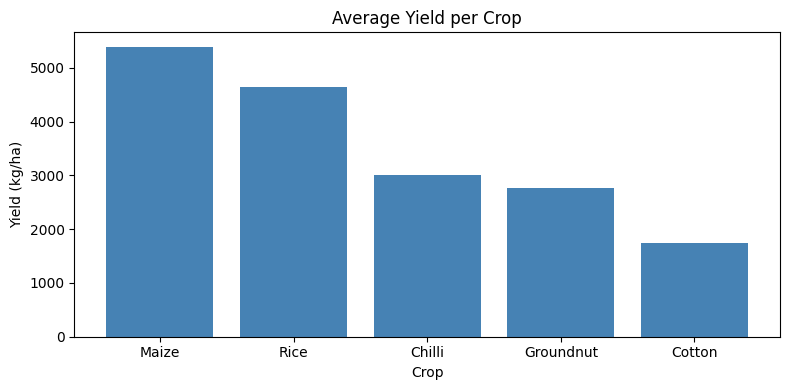

In [11]:
# Average yield per crop
crop_avg = df.groupby('Crop')['Yield_kg_ha'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(crop_avg.index, crop_avg.values, color='steelblue')
plt.title('Average Yield per Crop')
plt.xlabel('Crop')
plt.ylabel('Yield (kg/ha)')
plt.tight_layout()
plt.show()


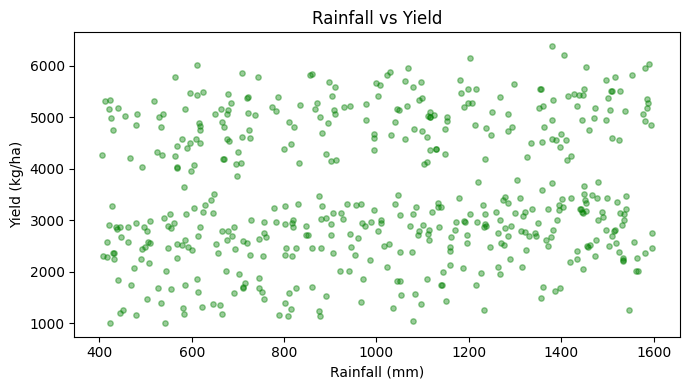

In [12]:
# Rainfall vs Yield
plt.figure(figsize=(7, 4))
plt.scatter(df['Rainfall_mm'], df['Yield_kg_ha'], alpha=0.4, s=15, color='green')
plt.title('Rainfall vs Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (kg/ha)')
plt.tight_layout()
plt.show()


## PreProcessing

In [13]:
le_district = LabelEncoder()
le_crop     = LabelEncoder()

df['District_enc'] = le_district.fit_transform(df['District'])
df['Crop_enc']     = le_crop.fit_transform(df['Crop'])

features = ['District_enc', 'Crop_enc', 'Rainfall_mm', 'Fertilizer_kg', 'Irrigation']
X = df[features]
y = df['Yield_kg_ha']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])


Train size: 400
Test size : 100


## Model Training

In [14]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)
print(f"Linear Regression  -> RMSE: {rmse_lr:.2f}  |  R2: {r2_lr:.4f}")

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)
print(f"Random Forest      -> RMSE: {rmse_rf:.2f}  |  R2: {r2_rf:.4f}")


Linear Regression  -> RMSE: 890.04  |  R2: 0.5704
Random Forest      -> RMSE: 233.79  |  R2: 0.9704


In [16]:
from sklearn.linear_model import Lasso

# Lasso Regression
ls_model = Lasso(alpha=1.0)

ls_model.fit(X_train, y_train)
y_pred_ls = ls_model.predict(X_test)

rmse_ls = np.sqrt(mean_squared_error(y_test, y_pred_ls))
r2_ls = r2_score(y_test, y_pred_ls)

print(f"Lasso Regression -> RMSE: {rmse_ls:.2f} | R2: {r2_ls:.4f}")


Lasso Regression -> RMSE: 890.00 | R2: 0.5705


## Results(Output)

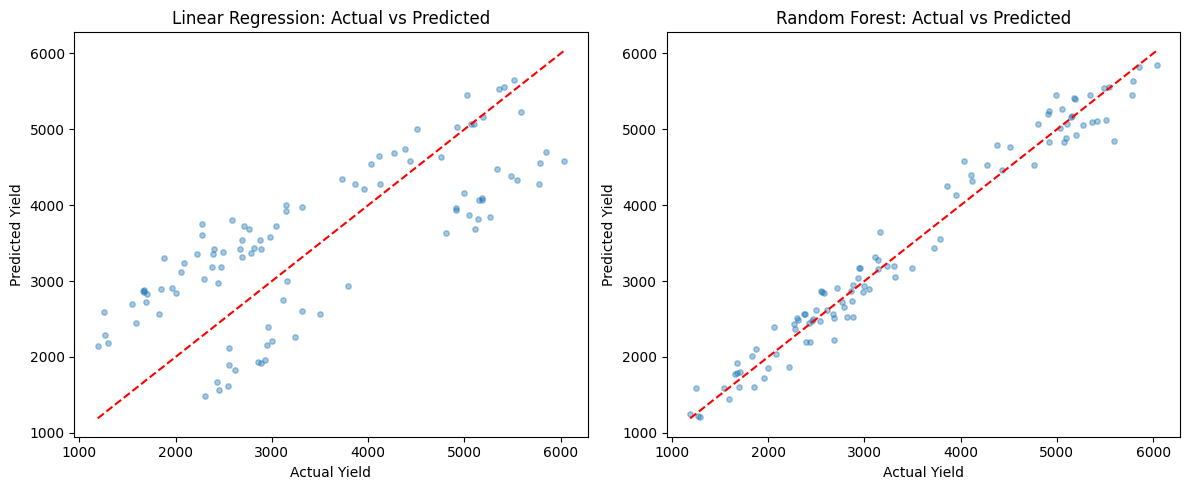

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, name in zip(axes,
                            [y_pred_lr, y_pred_rf],
                            ['Linear Regression', 'Random Forest']):
    ax.scatter(y_test, preds, alpha=0.4, s=15)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_title(f'{name}: Actual vs Predicted')
    ax.set_xlabel('Actual Yield')
    ax.set_ylabel('Predicted Yield')

plt.tight_layout()
plt.show()


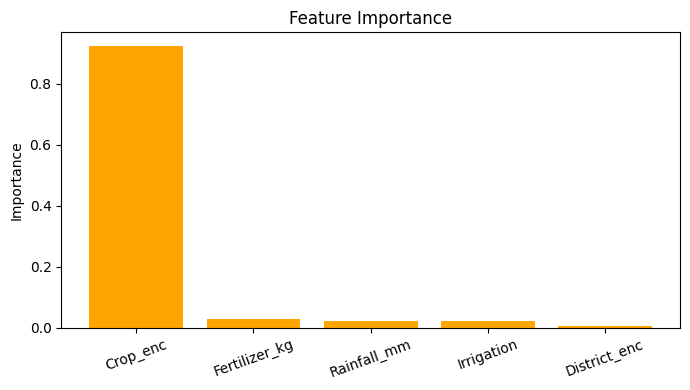

In [18]:
# Feature importance from Random Forest
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
plt.bar(importances.index, importances.values, color='orange')
plt.title('Feature Importance')
plt.ylabel('Importance')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## Testing on New Input

In [19]:
# Change these values to predict yield for any input
district   = 'Guntur'
crop       = 'Rice'
rainfall   = 1000.0   # mm
fertilizer = 150.0    # kg/ha
irrigation = 1        # 1 = yes, 0 = no

dist_enc = le_district.transform([district])[0]
crop_enc = le_crop.transform([crop])[0]

inp = pd.DataFrame([[dist_enc, crop_enc, rainfall, fertilizer, irrigation]],
                   columns=features)

pred = rf.predict(inp)[0]
print(f"District  : {district}")
print(f"Crop      : {crop}")
print(f"Rainfall  : {rainfall} mm")
print(f"Fertilizer: {fertilizer} kg/ha")
print(f"Irrigation: {'Yes' if irrigation else 'No'}")
print(f"Predicted Yield: {pred:.0f} kg/ha")


District  : Guntur
Crop      : Rice
Rainfall  : 1000.0 mm
Fertilizer: 150.0 kg/ha
Irrigation: Yes
Predicted Yield: 4838 kg/ha
